# 02 — Exploratory Data Analysis

Input: `dcs_student_data_cleaned.csv`. Every plot is followed by its takeaway.
The central question: *which features carry signal about student scores?*

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.read_csv("dcs_student_data_cleaned.csv")
print(f"Shape: {df.shape}")

Shape: (10000, 21)


## Correlation heatmap — the whole story in one figure

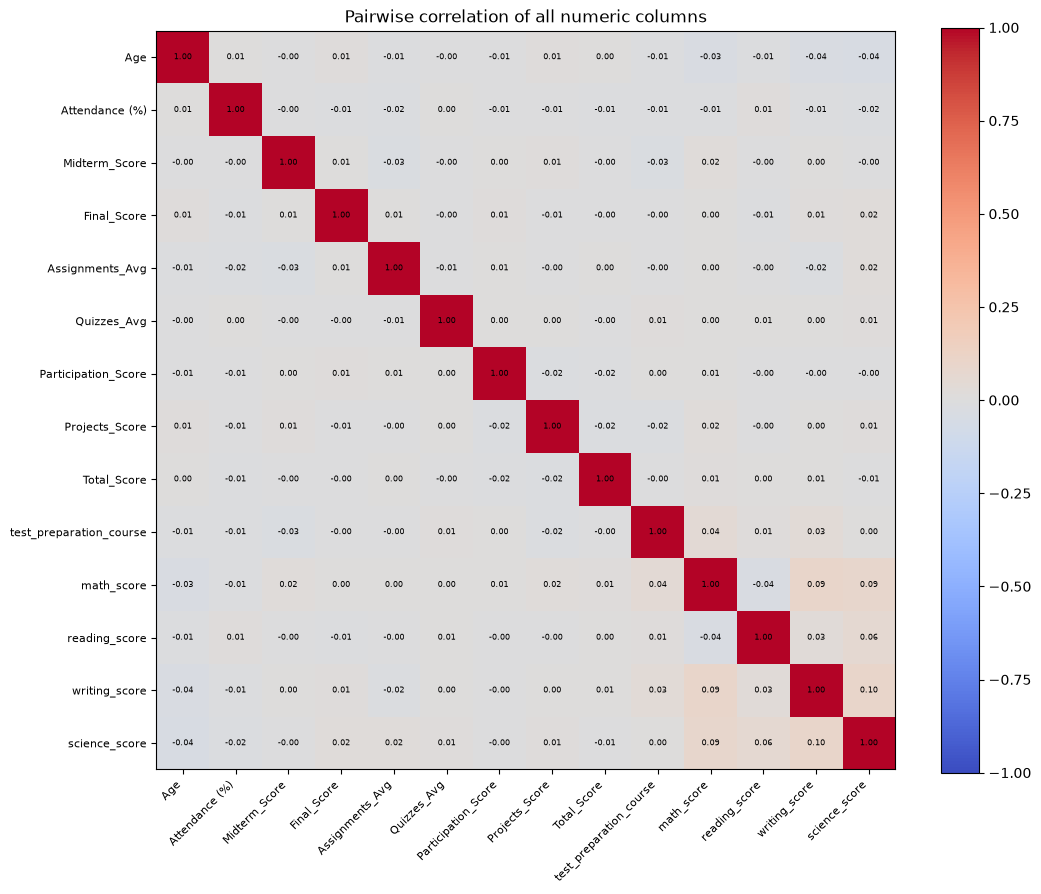

In [2]:
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(corr)), corr.columns, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=6)
fig.colorbar(im)
plt.title("Pairwise correlation of all numeric columns")
plt.tight_layout()
plt.show()

**Takeaway:** every off-diagonal correlation is near zero (|r| < 0.02). No numeric feature
has a linear relationship with any score — including `Total_Score` vs its own component
columns, which a real dataset would never show.

## Score columns vs Final_Score and Total_Score

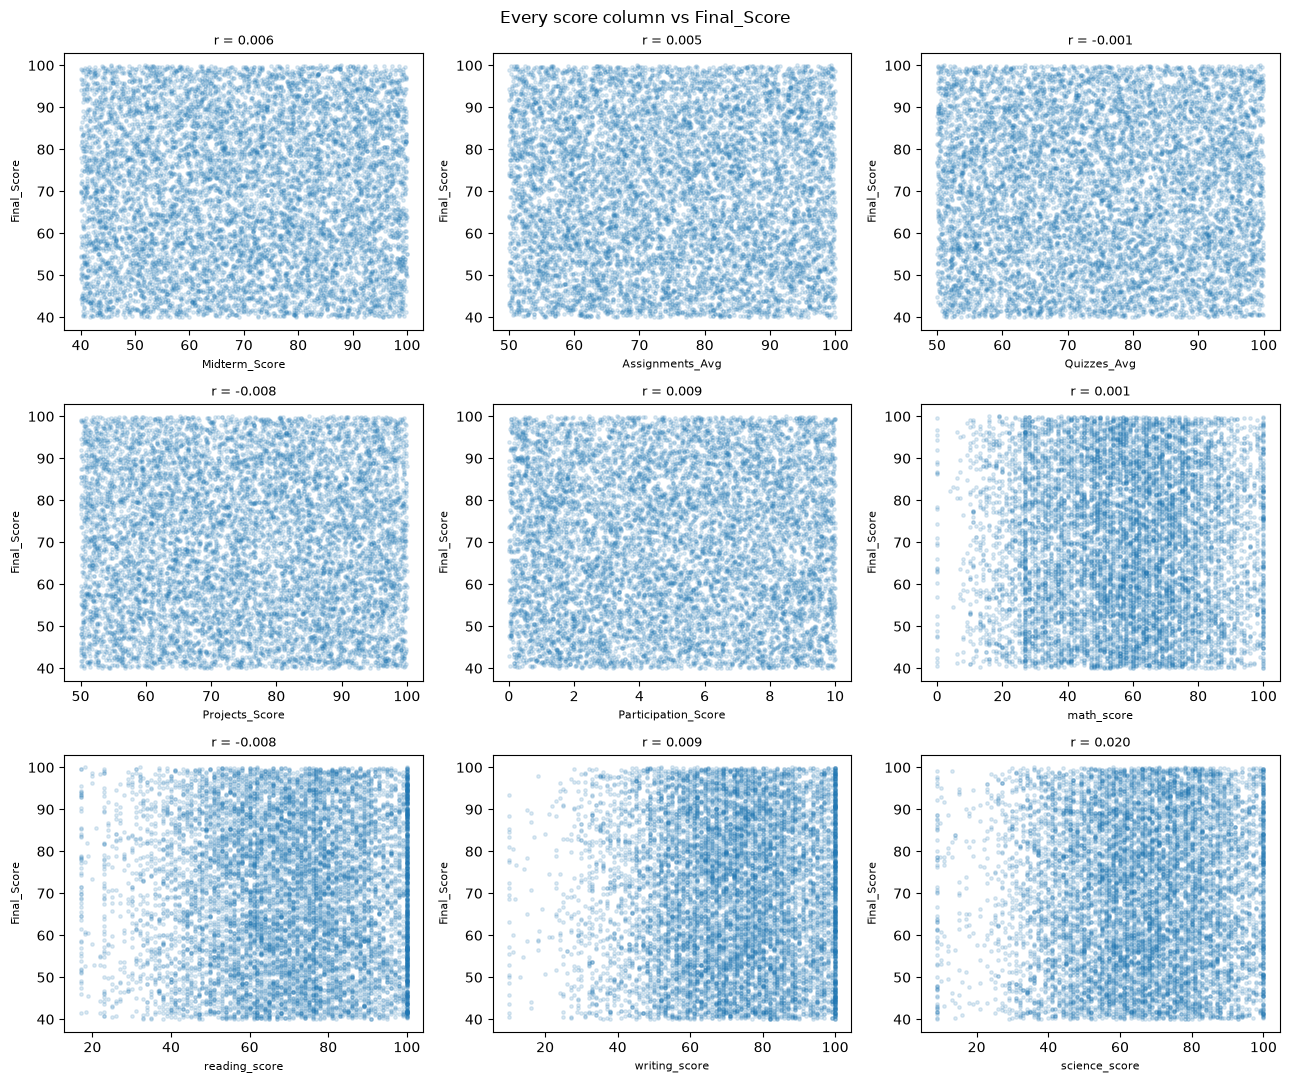

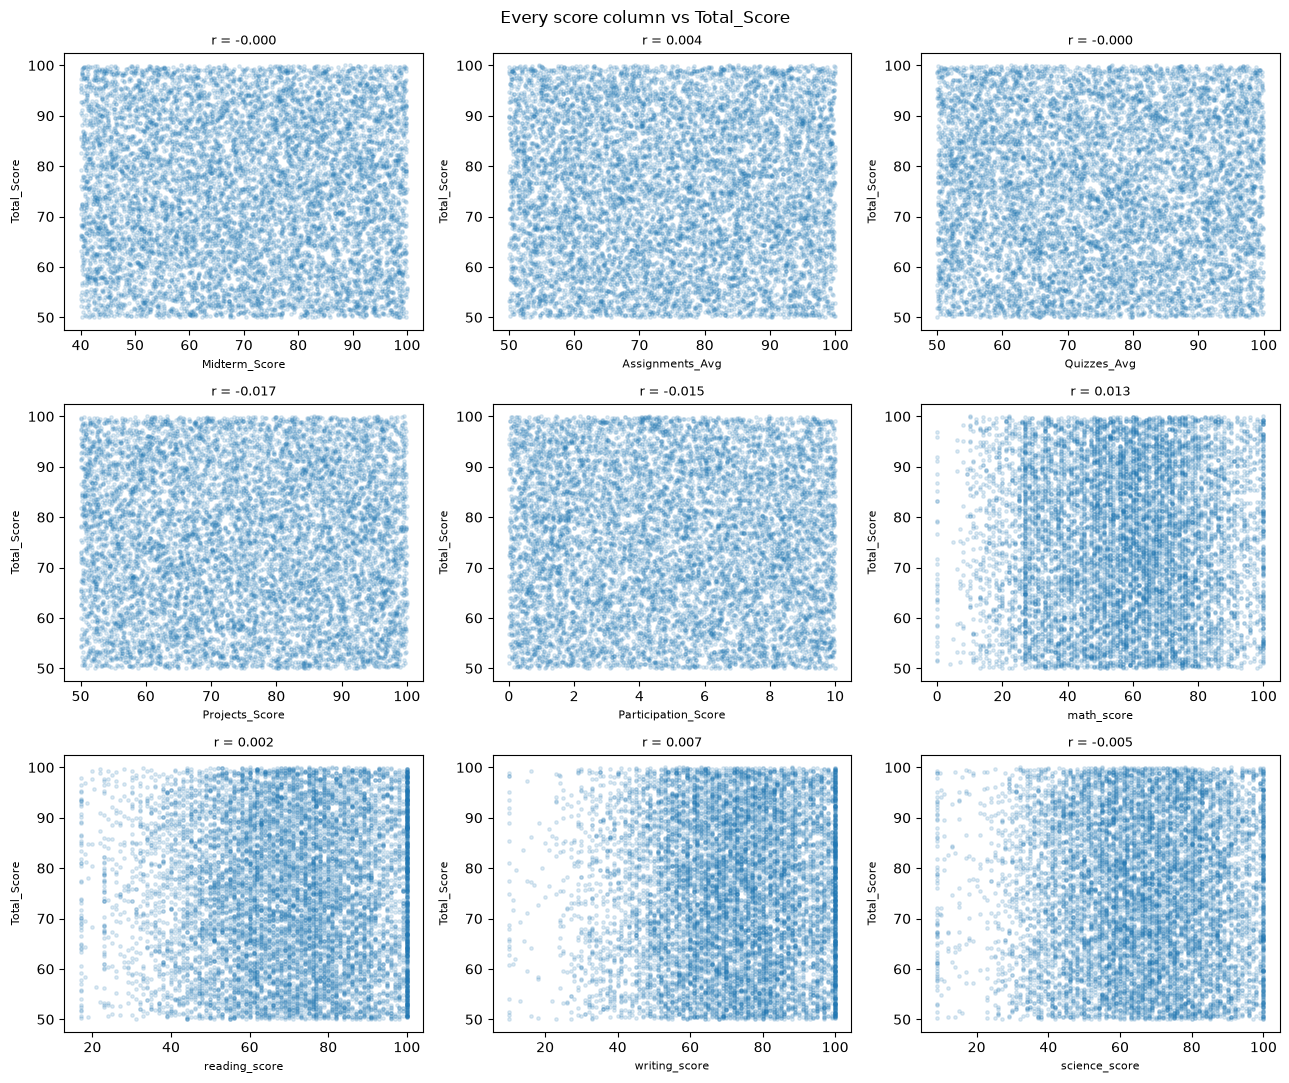

In [3]:
score_cols = ["Midterm_Score", "Assignments_Avg", "Quizzes_Avg",
              "Projects_Score", "Participation_Score",
              "math_score", "reading_score", "writing_score", "science_score"]

for target in ["Final_Score", "Total_Score"]:
    fig, axes = plt.subplots(3, 3, figsize=(13, 11))
    for ax, col in zip(axes.flat, score_cols):
        ax.scatter(df[col], df[target], alpha=0.15, s=6)
        r = df[col].corr(df[target])
        ax.set_xlabel(col, fontsize=8); ax.set_ylabel(target, fontsize=8)
        ax.set_title(f"r = {r:.3f}", fontsize=9)
    fig.suptitle(f"Every score column vs {target}")
    plt.tight_layout()
    plt.show()

**Takeaway:** diffuse clouds, no trend, correlation coefficients all ≈ 0. There is no
visible or numeric relationship between any individual score component and the final or
total score.

## Categorical breakdowns — Department and Gender

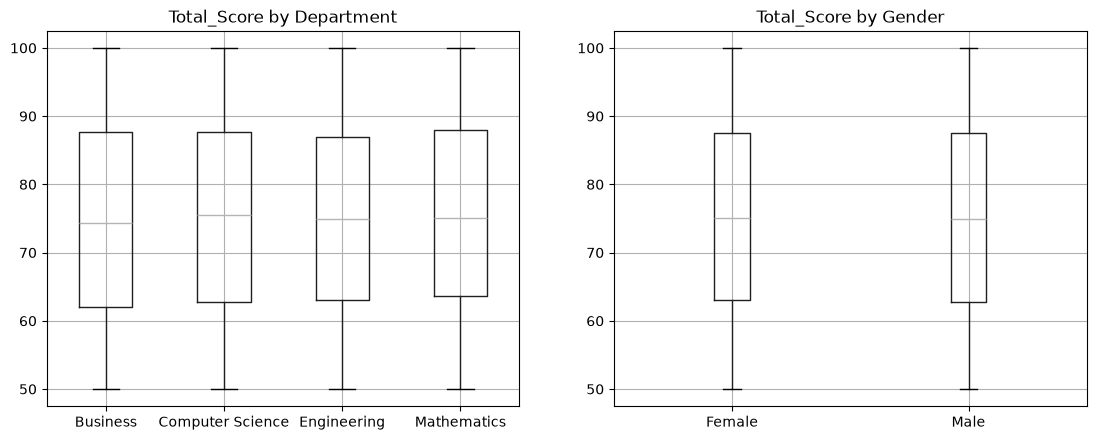

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
df.boxplot(column="Total_Score", by="Department", ax=axes[0])
axes[0].set_title("Total_Score by Department"); axes[0].set_xlabel("")
df.boxplot(column="Total_Score", by="Gender", ax=axes[1])
axes[1].set_title("Total_Score by Gender"); axes[1].set_xlabel("")
plt.suptitle("")
plt.show()

**Takeaway:** distributions overlap almost perfectly across departments and genders —
no group separation. Categorical features carry no signal either.

## Attendance vs marks (explicitly requested by the task)

Correlation Attendance vs Final_Score: -0.0123
Correlation Attendance vs Total_Score: -0.0109


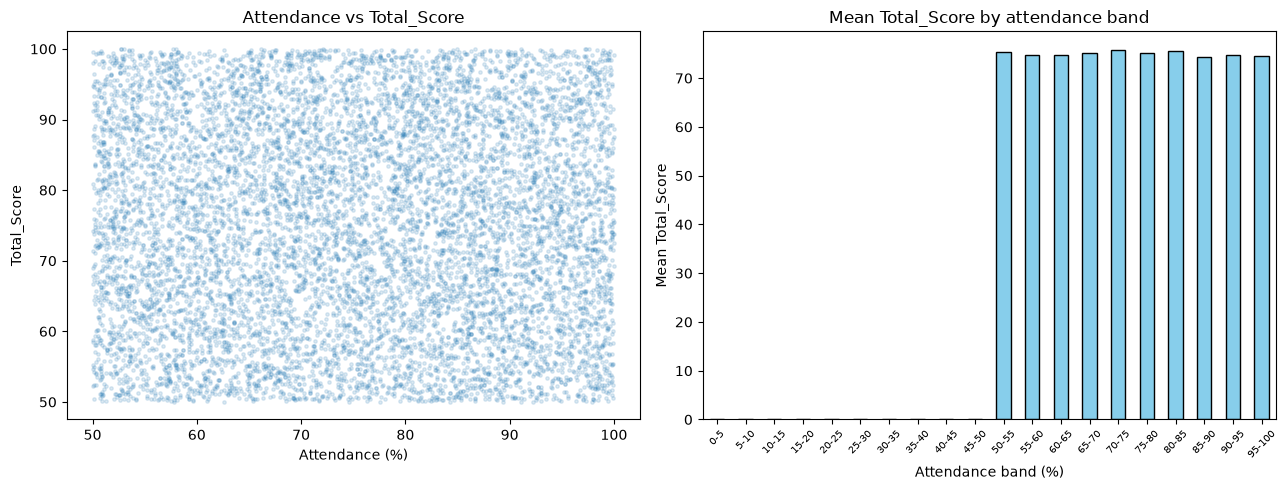

In [5]:
att_final_r = df["Attendance (%)"].corr(df["Final_Score"])
att_total_r = df["Attendance (%)"].corr(df["Total_Score"])
print(f"Correlation Attendance vs Final_Score: {att_final_r:.4f}")
print(f"Correlation Attendance vs Total_Score: {att_total_r:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(df["Attendance (%)"], df["Total_Score"], alpha=0.15, s=6)
axes[0].set_xlabel("Attendance (%)"); axes[0].set_ylabel("Total_Score")
axes[0].set_title("Attendance vs Total_Score")

bins = list(range(0, 101, 5))
labels = [f"{i}-{i+5}" for i in range(0, 100, 5)]
att_range = pd.cut(df["Attendance (%)"], bins=bins, labels=labels, include_lowest=True)
df.groupby(att_range, observed=False)["Total_Score"].mean().plot(
    kind="bar", ax=axes[1], color="skyblue", edgecolor="black")
axes[1].set_title("Mean Total_Score by attendance band")
axes[1].set_xlabel("Attendance band (%)"); axes[1].set_ylabel("Mean Total_Score")
axes[1].tick_params(axis="x", rotation=45, labelsize=7)
plt.tight_layout()
plt.show()

**Takeaway:** attendance has near-zero correlation with both Final and Total scores,
and mean score is flat across every attendance band. In this dataset attendance carries
no information about marks — so it is excluded from model features (kept in the final
report, since the task's output format includes it). In real data this relationship is
usually strong; its absence here is diagnostic of synthetic generation.

## Final EDA conclusion

**The dataset has no predictive signal.** Verified linearly (all correlations ≈ 0) and
visually (flat scatters, overlapping boxplots, flat attendance bands). `Total_Score` is
uniformly distributed in [50, 100] and independent of every other column; `Grade` spans
the full score range in every grade band. The data was synthetically generated with
independent random columns.

This conclusion drives everything downstream: no model can learn to predict risk from
these features (proved empirically in notebook 04), so the risk system in notebook 03 is
built on explicit, defensible criteria — exactly what the task asks for
("define your own criteria ... and explain your approach").